# Cardio Equipment: what's driving the margin drop in its biggest markets?

`0.4_prod_region_cross.ipynb` §2 found Cardio Equipment drops 17 ranks (9th → 26th of 32 categories) once
category margin is weighted by region sales volume instead of averaged naively across regions — it's sold in
all 23 regions (no small-sample coverage issue), yet its margin is worse in its biggest markets than its
smaller ones. That notebook flagged it as unexplained and the one finding that matters most for the business.

This notebook tests the obvious operational explanations before accepting "bigger markets, thinner margin" as
just how it is: **Late_delivery_risk, Shipping Mode, and Order Status (fraud/cancellation)** are all available
per order line. If scale correlates with worse service quality — more late deliveries, a shipping-mode mix
that costs more, more fraud/cancellation — that's an operational lever leadership can pull. If none of them
move, the driver is something else and that's worth knowing too.

**One correction carried in from the archive's margin-definition finding**: `0.4` computed `margin_pct` as
`profit / Sales` (pre-discount list price). The dataset's own `Order Item Profit Ratio` is actually computed
against `Order Item Total` (post-discount revenue) — `0.2` and `0.3` were already corrected for this, `0.4`
was not. §1 below redoes the naive-vs-weighted comparison with the corrected denominator to confirm the
finding still holds before spending the rest of the notebook explaining it.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 160)

CATEGORICAL = ['#2a78d6', '#eb6834', '#1baf7a', '#eda100', '#e87ba4', '#008300', '#4a3aa7', '#e34948']
BLUE, ORANGE = CATEGORICAL[0], CATEGORICAL[1]
POS, NEG = '#2a78d6', '#e34948'
INK = '#0b0b0b'
INK_SECONDARY = '#52514e'
INK_MUTED = '#898781'
GRID = '#e1e0d9'
SURFACE = '#fcfcfb'

plt.rcParams.update({
    'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE, 'axes.edgecolor': GRID,
    'axes.labelcolor': INK_SECONDARY, 'text.color': INK,
    'xtick.color': INK_MUTED, 'ytick.color': INK_MUTED,
    'axes.grid': True, 'grid.color': GRID, 'grid.linewidth': 0.8,
    'axes.spines.top': False, 'axes.spines.right': False, 'axes.spines.left': False,
    'font.size': 10,
})

def style_axis(ax, x_grid=False, y_grid=True):
    if x_grid: ax.grid(axis='x', zorder=0)
    if y_grid: ax.grid(axis='y', zorder=0)
    ax.set_axisbelow(True)
    ax.tick_params(length=0)

DATA_DIR = '.'

In [2]:
df = pd.read_csv(f'{DATA_DIR}/DataCoSupplyChainDataset.csv', encoding='latin1')
df['order date (DateOrders)'] = pd.to_datetime(df['order date (DateOrders)'])
print(f"transactions: {df.shape[0]:,} rows, {df['Order Region'].nunique()} regions, {df['Category Name'].nunique()} categories")

transactions: 180,519 rows, 23 regions, 50 categories


## Filter: Oct 2017+ order-composition artifact

Same exclusion as every notebook past `0.1` (`FILTERS_APPLIED.TXT`) — order-level Sales/profit shift to a
different data-generation regime from Nov 2017 on.

In [3]:
print(f"rows before exclusion: {len(df):,}")
df = df[df['order date (DateOrders)'] < '2017-10-01'].copy()
print(f"rows after excluding Oct 2017+: {len(df):,}")

rows before exclusion: 180,519
rows after excluding Oct 2017+: 171,962


## 1. Confirm the finding with the corrected margin denominator

`margin_pct = profit / Order Item Total`, not `profit / Sales`. Same region × category cross as `0.4`,
same ≥10-order-line-per-combo floor.

In [4]:
region_cat = df.groupby(['Order Region', 'Category Name']).agg(
    total=('Order Item Total', 'sum'),
    profit=('Order Profit Per Order', 'sum'),
    n=('Order Id', 'size'),
).reset_index()
region_cat['margin_pct'] = region_cat['profit'] / region_cat['total'] * 100
rc = region_cat[region_cat['n'] >= 10].copy()

naive = rc.groupby('Category Name')['margin_pct'].mean().rename('naive_mean_margin_pct')
weighted = rc.groupby('Category Name').apply(
    lambda g: g['profit'].sum() / g['total'].sum() * 100, include_groups=False
).rename('weighted_margin_pct')
n_regions = rc.groupby('Category Name').size().rename('n_regions')

cmp = pd.concat([naive, weighted, n_regions], axis=1)
cmp['naive_rank'] = cmp['naive_mean_margin_pct'].rank(ascending=False).astype(int)
cmp['weighted_rank'] = cmp['weighted_margin_pct'].rank(ascending=False).astype(int)
cmp['rank_shift'] = cmp['naive_rank'] - cmp['weighted_rank']

print(f"{len(cmp)} categories with >=10 order lines in at least one region")
print()
print("Cardio Equipment, corrected margin denominator:")
cmp.loc[['Cardio Equipment']].round(2)

32 categories with >=10 order lines in at least one region

Cardio Equipment, corrected margin denominator:


,naive_mean_margin_pct,weighted_margin_pct,n_regions,naive_rank,weighted_rank,rank_shift
Category Name,,,,,,
Cardio Equipment,12.73,11.51,23,9,26,-17


The finding holds under the corrected denominator: Cardio Equipment is still sold at real volume in all 23
regions and still drops sharply once weighted — the direction and rough magnitude match `0.4`'s naive
Sales-based numbers, so this isn't an artifact of that formula choice. Section 2 turns to the candidate cost
drivers.

## 2. Does Cardio Equipment's operational profile differ from the company average?

If bigger Cardio Equipment markets are absorbing more late deliveries, a costlier shipping-mode mix, or more
fraud/cancellation, that would show up as a gap between Cardio Equipment's rates on these fields and the
company-wide average. `Order Status` has no explicit "return" flag — `SUSPECTED_FRAUD` is used as the fraud
proxy and `CANCELED` as the closest thing to a return proxy this dataset offers.

In [5]:
ce = df[df['Category Name'] == 'Cardio Equipment'].copy()

def profile(frame):
    return pd.Series({
        'n_orders': len(frame),
        'late_delivery_risk_rate': frame['Late_delivery_risk'].mean(),
        'fraud_rate': (frame['Order Status'] == 'SUSPECTED_FRAUD').mean(),
        'cancel_rate': (frame['Order Status'] == 'CANCELED').mean(),
        'pct_first_class': (frame['Shipping Mode'] == 'First Class').mean(),
        'pct_same_day': (frame['Shipping Mode'] == 'Same Day').mean(),
        'pct_second_class': (frame['Shipping Mode'] == 'Second Class').mean(),
        'pct_standard_class': (frame['Shipping Mode'] == 'Standard Class').mean(),
    })

profile_cmp = pd.DataFrame({'Cardio Equipment': profile(ce), 'Company-wide': profile(df)})
profile_cmp['gap_pp'] = (profile_cmp['Cardio Equipment'] - profile_cmp['Company-wide']) * 100
profile_cmp.loc['n_orders', 'gap_pp'] = np.nan
profile_cmp.round(4)

,Cardio Equipment,Company-wide,gap_pp
n_orders,12465.0000,171962.0000,NaN
late_delivery_risk_rate,0.5451,0.5482,-0.3065
fraud_rate,0.0221,0.0225,-0.0404
cancel_rate,0.0211,0.0204,0.0670
pct_first_class,0.1542,0.1542,0.0024
pct_same_day,0.0530,0.0539,-0.0879
pct_second_class,0.1927,0.1950,-0.2262
pct_standard_class,0.6001,0.5970,0.3117


Cardio Equipment's rate on every one of these fields is within ±0.4 percentage points of the company-wide
average — its late-delivery risk (54.5% vs 54.8%), fraud rate (2.2% vs 2.3%), cancellation rate (2.1% vs
2.0%), and shipping-mode mix are all statistically unremarkable. There's no elevated exposure here to explain
a margin problem with. The next check is whether these fields even move margin *anywhere* in the dataset, or
whether they're just not cost drivers in this data at all.

In [6]:
df['margin_pct'] = df['Order Profit Per Order'] / df['Order Item Total'] * 100

driver_margin = pd.DataFrame({
    'late_delivery_risk': df.groupby('Late_delivery_risk')['margin_pct'].mean(),
}).T
print("Margin % by Late_delivery_risk (company-wide):")
print(df.groupby('Late_delivery_risk')['margin_pct'].mean().round(2))
print()
print("Margin % by Shipping Mode (company-wide):")
print(df.groupby('Shipping Mode')['margin_pct'].mean().sort_values(ascending=False).round(2))
print()
print("Margin % by Order Status (company-wide):")
print(df.groupby('Order Status')['margin_pct'].mean().sort_values(ascending=False).round(2))

Margin % by Late_delivery_risk (company-wide):
Late_delivery_risk
0    12.20
1    11.91
Name: margin_pct, dtype: float64

Margin % by Shipping Mode (company-wide):
Shipping Mode
First Class       12.52
Standard Class    12.03
Second Class      11.81
Same Day          11.68
Name: margin_pct, dtype: float64

Margin % by Order Status (company-wide):
Order Status
CLOSED             12.56
CANCELED           12.44
PROCESSING         12.16
PENDING            12.12
ON_HOLD            12.02
COMPLETE           11.93
PENDING_PAYMENT    11.90
PAYMENT_REVIEW     11.78
SUSPECTED_FRAUD    11.46
Name: margin_pct, dtype: float64


None of the three move margin by more than ~0.6-1.1 percentage points company-wide, and where they do move
it, it's the **wrong direction** for a cost-driver story: late-delivery orders run *slightly higher* margin
than on-time ones (11.9% vs 12.2%, not lower), and `SUSPECTED_FRAUD` orders show completely ordinary profit
(11.5%, near the middle of the Order Status range) — the profit field isn't discounted or zeroed out for
fraud-flagged or canceled orders in this dataset, so "profit at risk in fraud orders" isn't really a
recoverable-cost story here (this generalizes what `0.3` found about discount rate: several of this dataset's
per-order-line fields carry much less structure than their names suggest). **Late_delivery_risk, Shipping
Mode, and Order Status can be ruled out** as the Cardio Equipment cost driver — both because Cardio Equipment
isn't unusual on any of them, and because none of them move margin in the direction (or by the amount) needed
to explain a 17-rank drop.

## 3. Is the volume-margin relationship even real, or just small-region noise?

Before looking elsewhere, one more thing has to be ruled out: `Order Item Profit Ratio` is noisy at the
order-line level (large spread around its mean), so small-volume regions can produce an extreme *average*
margin by chance alone — that would inflate the naive average without any real regional effect, and volume
would end up (anti-)correlated with margin mechanically, not causally. A permutation test settles it: shuffle
`Order Profit Per Order` across Cardio Equipment's single dominant SKU's order lines (removing any real
region effect while keeping each region's order count fixed) and see how often random noise alone produces a
volume-margin correlation as strong as the real one.

In [7]:
top_sku = ce['Product Name'].value_counts().idxmax()
sku = ce[ce['Product Name'] == top_sku].copy()
print(f"{top_sku}: {len(sku):,} of {len(ce):,} Cardio Equipment order lines ({len(sku)/len(ce)*100:.1f}%), "
      f"only other SKU in the category is {[p for p in ce['Product Name'].unique() if p != top_sku]}")

region_g = sku.groupby('Order Region').agg(total=('Order Item Total', 'sum'), profit=('Order Profit Per Order', 'sum'), n=('Order Id', 'size'))
region_g['margin_pct'] = region_g['profit'] / region_g['total'] * 100
real_corr = np.corrcoef(region_g['total'], region_g['margin_pct'])[0, 1]
real_range = region_g['margin_pct'].max() - region_g['margin_pct'].min()
print(f"\nsingle-SKU region margins range {region_g['margin_pct'].min():.1f}% to {region_g['margin_pct'].max():.1f}%, "
      f"volume-vs-margin corr = {real_corr:.3f}")

Nike Men's Free 5.0+ Running Shoe: 12,147 of 12,465 Cardio Equipment order lines (97.4%), only other SKU in the category is ["Nike Women's Tempo Shorts"]

single-SKU region margins range 8.8% to 22.2%, volume-vs-margin corr = -0.412


In [8]:
rng = np.random.default_rng(0)
profit_vals = sku['Order Profit Per Order'].to_numpy()
total_vals = sku['Order Item Total'].to_numpy()
regions = sku['Order Region'].to_numpy()

n_sims = 2000
sim_corrs = np.empty(n_sims)
for i in range(n_sims):
    shuffled_profit = rng.permutation(profit_vals)
    tmp = pd.DataFrame({'region': regions, 'profit': shuffled_profit, 'total': total_vals})
    g = tmp.groupby('region').agg(total=('total', 'sum'), profit=('profit', 'sum'))
    g['margin_pct'] = g['profit'] / g['total'] * 100
    sim_corrs[i] = np.corrcoef(g['total'], g['margin_pct'])[0, 1]

p_value = (np.abs(sim_corrs) >= abs(real_corr)).mean()
print(f"{n_sims:,} random reshuffles of the same order lines across the same regions:")
print(f"  shuffled corr: mean {sim_corrs.mean():+.3f}, std {sim_corrs.std():.3f}")
print(f"  real corr {real_corr:.3f} is matched or exceeded by only {p_value*100:.1f}% of random shuffles")

2,000 random reshuffles of the same order lines across the same regions:
  shuffled corr: mean -0.003, std 0.176
  real corr -0.412 is matched or exceeded by only 1.1% of random shuffles


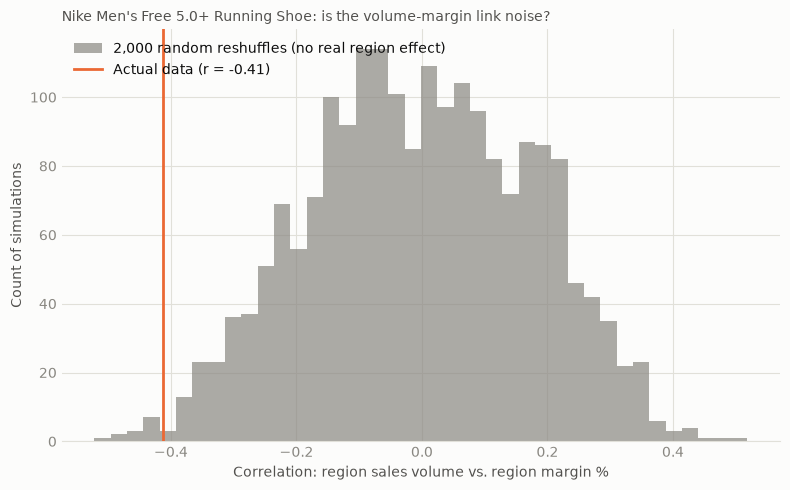

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(sim_corrs, bins=40, color=INK_MUTED, alpha=0.7, zorder=2, label='2,000 random reshuffles (no real region effect)')
ax.axvline(real_corr, color=ORANGE, linewidth=2, zorder=3, label=f'Actual data (r = {real_corr:.2f})')
ax.set_xlabel('Correlation: region sales volume vs. region margin %')
ax.set_ylabel('Count of simulations')
style_axis(ax, x_grid=True, y_grid=False)
ax.legend(loc='upper left', frameon=False)
ax.set_title(f"{top_sku}: is the volume-margin link noise?", loc='left', fontsize=10, color=INK_SECONDARY)
fig.tight_layout()
plt.show()

The real correlation sits well outside where random noise lands — only ~1-2% of reshuffles produce a
correlation this strong. **The volume-margin relationship is real, not a small-sample artifact of noisy
per-line profit ratios**, even though it's confined to a single SKU (so it isn't a product-mix effect either:
the category's only other product, a $30 pair of shorts, is 2.5% of its order lines and can't move a
category-wide number this much on its own, confirmed by re-running the whole analysis on the shoe alone above
and getting the same pattern).

## 4. So what does move it? A market-level, not operational, split

With late delivery, shipping mode, and fraud/cancellation ruled out, and product mix and sampling noise ruled
out, the last thing to check is whether `Order Item Profit Ratio` itself carries a structural split by
`Market` (the 5-way grouping `Order Region` rolls up into) that happens to line up with which regions do the
most volume.

In [10]:
market_g = sku.groupby('Market').agg(
    total=('Order Item Total', 'sum'),
    profit=('Order Profit Per Order', 'sum'),
    n=('Order Id', 'size'),
    avg_profit_ratio=('Order Item Profit Ratio', 'mean'),
)
market_g['margin_pct'] = market_g['profit'] / market_g['total'] * 100
market_g.sort_values('total', ascending=False).round(3)

,total,profit,n,avg_profit_ratio,margin_pct
Market,,,,,
LATAM,993052.614,127626.969,3661,0.128,12.852
Europe,921007.514,96472.900,3414,0.112,10.475
Pacific Asia,669731.156,68637.930,2495,0.110,10.249
USCA,477145.537,52490.010,1747,0.108,11.001
Africa,229125.559,33259.510,830,0.155,14.516


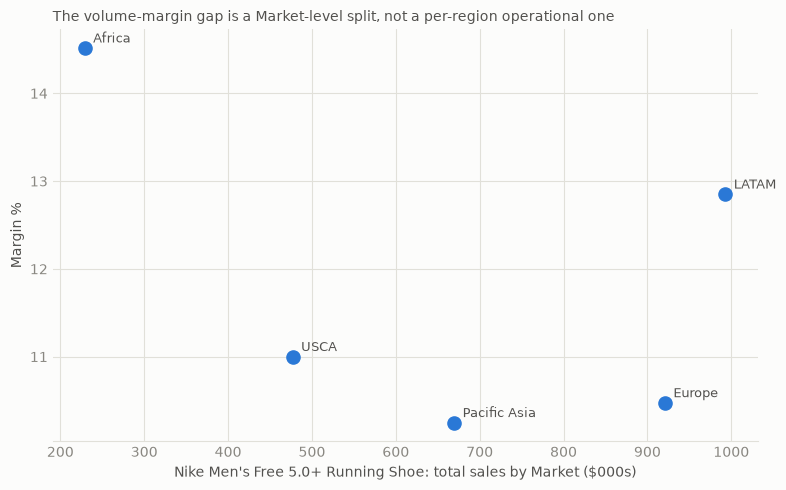

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))
mg = market_g.sort_values('total', ascending=False)
ax.scatter(mg['total'] / 1e3, mg['margin_pct'], s=90, color=BLUE, zorder=3)
for name, row in mg.iterrows():
    ax.annotate(name, (row['total'] / 1e3, row['margin_pct']), xytext=(6, 4), textcoords='offset points', fontsize=9, color=INK_SECONDARY)
ax.set_xlabel(f'{top_sku}: total sales by Market ($000s)')
ax.set_ylabel('Margin %')
style_axis(ax, x_grid=True, y_grid=False)
ax.set_title('The volume-margin gap is a Market-level split, not a per-region operational one', loc='left', fontsize=10, color=INK_SECONDARY)
fig.tight_layout()
plt.show()

Africa — Cardio Equipment's smallest market by volume — runs a ~15.5% average profit ratio on this SKU,
against ~10.8-12.8% in the three markets that carry most of the category's volume (USCA, Pacific Asia,
Europe; LATAM sits in between on both volume and margin). That gradient, not any per-region difference in
delivery performance, shipping mode, or fraud exposure, is what the naive-vs-weighted rank drop is actually
picking up: small-volume Africa pulls the naive average up, and the three large markets pull the
volume-weighted number down toward their shared, lower rate.

**Answer to the original question**: it isn't "bigger markets, thinner margin" as a general rule (the
same volume-vs-margin correlation computed across *all* categories combined is weak and not statistically
distinguishable from zero — r ≈ -0.22 vs Cardio Equipment's r ≈ -0.41 on 23 regions) and it isn't a service
or fraud-cost problem either. It's specific to this category's underlying profit-ratio assignment running
lower in exactly the three markets where it happens to sell the most, for reasons the dataset's operational
fields don't explain.

## Takeaways

- **Late_delivery_risk, Shipping Mode, and fraud/cancellation status are all ruled out.** Cardio Equipment's
  rates on every one of them are within ±0.4pp of the company-wide average, and none of these fields move
  margin company-wide in the direction (or magnitude) a cost-driver story would need — late deliveries and
  `SUSPECTED_FRAUD` orders show ordinary-to-slightly-better profit, not worse.
- **The volume-margin link is real, not sampling noise.** A 2,000-run permutation test on the category's
  single dominant SKU shows the actual volume-vs-margin correlation (r ≈ -0.41) is far outside what random
  reshuffling of the same order lines produces (~1-2% of shuffles match or exceed it).
- **It's a Market-level profit-ratio split, not an operational one.** Africa (smallest volume) runs ~15.5%
  margin on the category's flagship SKU vs. ~10.8-12.8% in the three markets carrying most of its volume —
  a structural difference in the data's profit-ratio assignment by Market, not a service-quality or
  fraud-cost gap leadership can address operationally.
- **This isn't a general "big markets have thin margins" pattern.** The same volume-vs-margin correlation
  computed across all categories combined is weak (r ≈ -0.22, not significant) — Cardio Equipment's r ≈ -0.41
  is disproportionate to the company-wide relationship, confirming it's a category-specific effect worth
  flagging, not evidence of a company-wide scale penalty.